In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv('CustomerChurn.csv')
df.head()

,LoyaltyID,Customer ID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,318537,7590-VHVEG,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,152148,5575-GNVDE,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,326527,3668-QPYBK,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,845894,7795-CFOCW,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,503388,9237-HQITU,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("shape:",df.shape)
print("\ncolumns:",df.columns.tolist())
print("\ndata types:\n",df.dtypes)

shape: (7043, 21)

columns: ['LoyaltyID', 'Customer ID', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn']

data types:
 LoyaltyID              int64
Customer ID           object
Senior Citizen        object
Partner               object
Dependents            object
Tenure                 int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn                 object
dtype: 

In [3]:
print("Missing values:\n",df.isnull().sum())
print("Baic Stats:\n",df.describe())

Missing values:
 LoyaltyID            0
Customer ID          0
Senior Citizen       0
Partner              0
Dependents           0
Tenure               0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn                0
dtype: int64
Baic Stats:
            LoyaltyID       Tenure  Monthly Charges
count    7043.000000  7043.000000      7043.000000
mean   550382.651001    32.371149        64.761692
std    260776.118690    24.559481        30.090047
min    100346.000000     0.000000        18.250000
25%    323604.500000     9.000000        35.500000
50%    548704.000000    29.000000        70.350000
75%    776869.000000    55.000000        89.850000
max    999912.000000    72.000000       118.750000


In [4]:
df['TotalCharges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print("Null values in TotalCharges:", df['Total Charges'].isnull().sum())

Null values in TotalCharges: 0


In [5]:
df.dropna(subset=['Total Charges'], inplace=True)
print("Shape after cleaning:", df.shape)

Shape after cleaning: (7043, 22)


In [6]:
print(df['Churn'].value_counts())
print("\nChurn Rate:", round(df['Churn'].value_counts(normalize=True)['Yes']*100, 2), "%")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54 %


In [7]:
df.groupby('Contract')['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [8]:
print(df.groupby('Churn')['Monthly Charges'].mean())

Churn
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64


In [9]:
print(df.groupby('Churn')['Monthly Charges'].mean())

Churn
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64


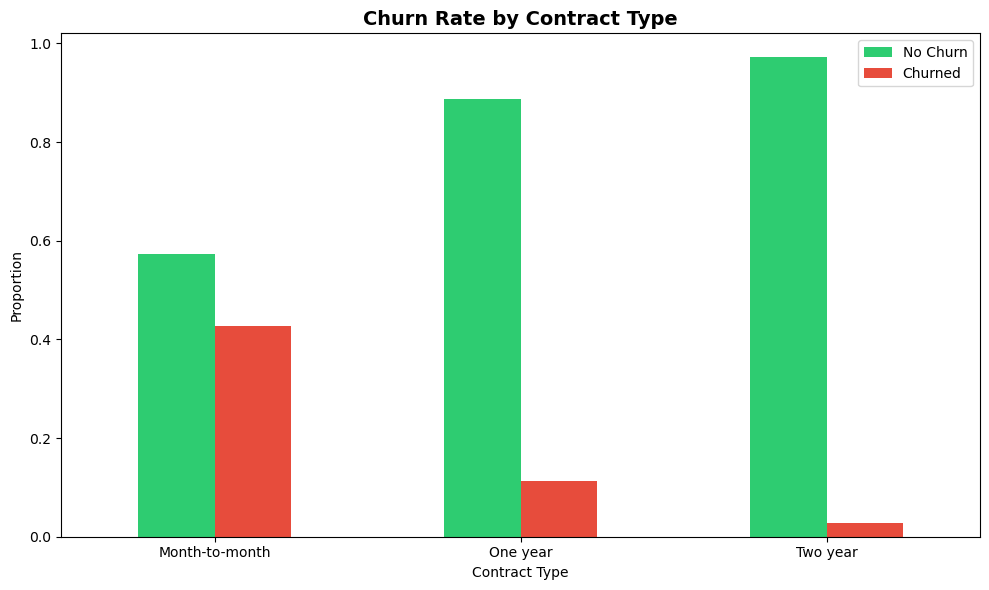

In [11]:
contract_churn=df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn.plot(kind='bar',figsize=(10,6),color=['#2ecc71','#e74c3c'])
plt.title('Churn Rate by Contract Type',fontsize=14,fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['No Churn','Churned'])
plt.tight_layout()
plt.savefig('contract_churn.png',dpi=150)
plt.show()

Churn
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64


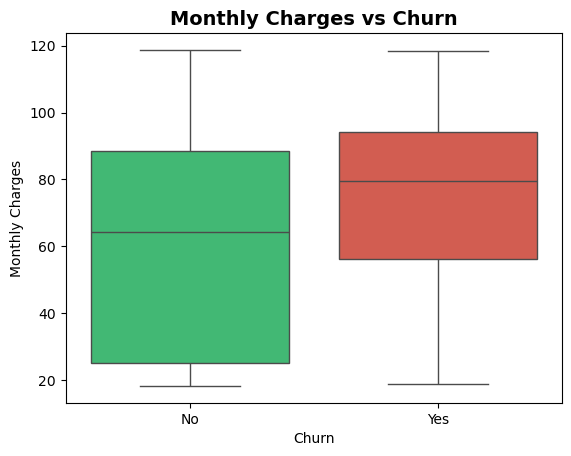

In [13]:
monthly_churn = df.groupby('Churn')['Monthly Charges'].mean()
print(monthly_churn)
sns.boxplot(data=df, x='Churn', y='Monthly Charges', hue='Churn', palette=['#2ecc71','#e74c3c'], legend=False)
plt.title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.savefig('monthly_charges_churn.png', dpi=150)
plt.show()


Churn               No       Yes
Tenure Group                    
0-12 months   0.523218  0.476782
13-24 months  0.712891  0.287109
25-48 months  0.796110  0.203890
49-72 months  0.904868  0.095132


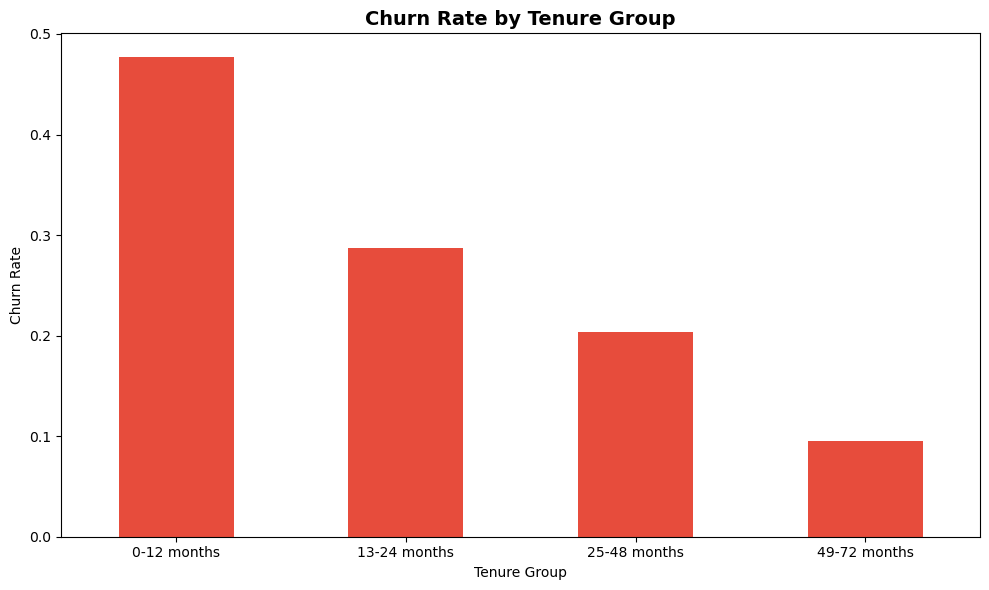

In [15]:
df['Tenure Group'] = pd.cut(df['Tenure'], bins=[0,12,24,48,72],
                            labels=['0-12 months','13-24 months','25-48 months','49-72 months'])

tenure_churn = df.groupby('Tenure Group', observed=True)['Churn'].value_counts(normalize=True).unstack()
print(tenure_churn)

tenure_churn['Yes'].plot(kind='bar', color='#e74c3c', figsize=(10,6))
plt.title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('tenure_churn.png', dpi=150)
plt.show()


Churn                   No       Yes
Internet Service                    
DSL               0.810409  0.189591
Fiber optic       0.581072  0.418928
No                0.925950  0.074050


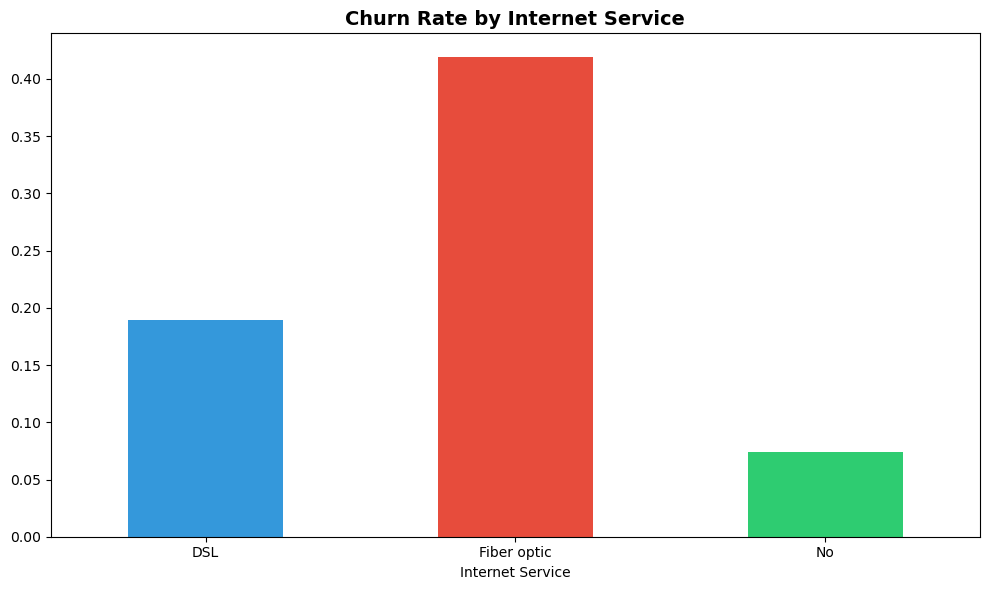

In [16]:
internet_churn = df.groupby('Internet Service')['Churn'].value_counts(normalize=True).unstack()
print(internet_churn)

internet_churn['Yes'].plot(kind='bar', color=['#3498db','#e74c3c','#2ecc71'], figsize=(10,6))
plt.title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('internet_churn.png', dpi=150)
plt.show()


In [17]:
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['Tenure'] <= 12) &
    (df['Monthly Charges'] > 65)
]

print(f'High Risk Customers: {len(high_risk)}')
print(f'Churn Rate in High Risk Segment: {round(high_risk["Churn"].value_counts(normalize=True)["Yes"]*100,2)}%')


High Risk Customers: 975
Churn Rate in High Risk Segment: 67.69%


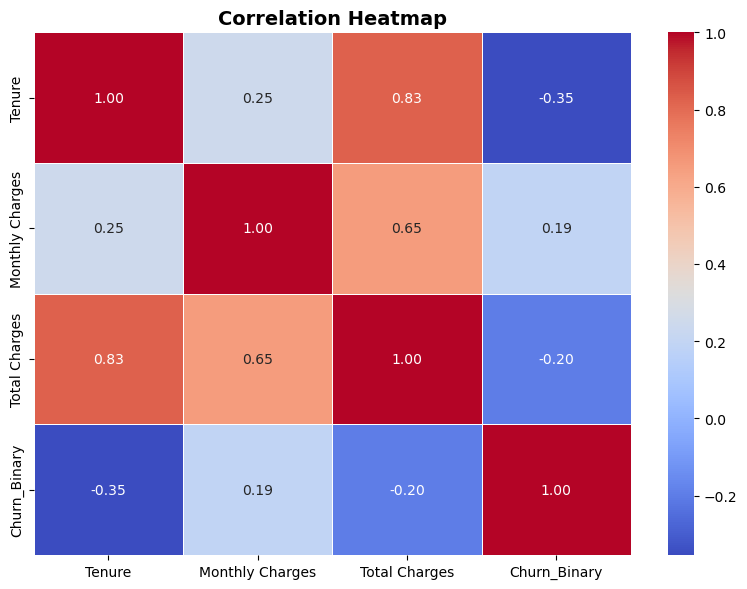

In [21]:
numeric_df = df[['Tenure', 'Monthly Charges', 'Total Charges']].copy()

numeric_df['Total Charges'] = pd.to_numeric(numeric_df['Total Charges'], errors='coerce')

numeric_df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

numeric_df = numeric_df.dropna()

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()

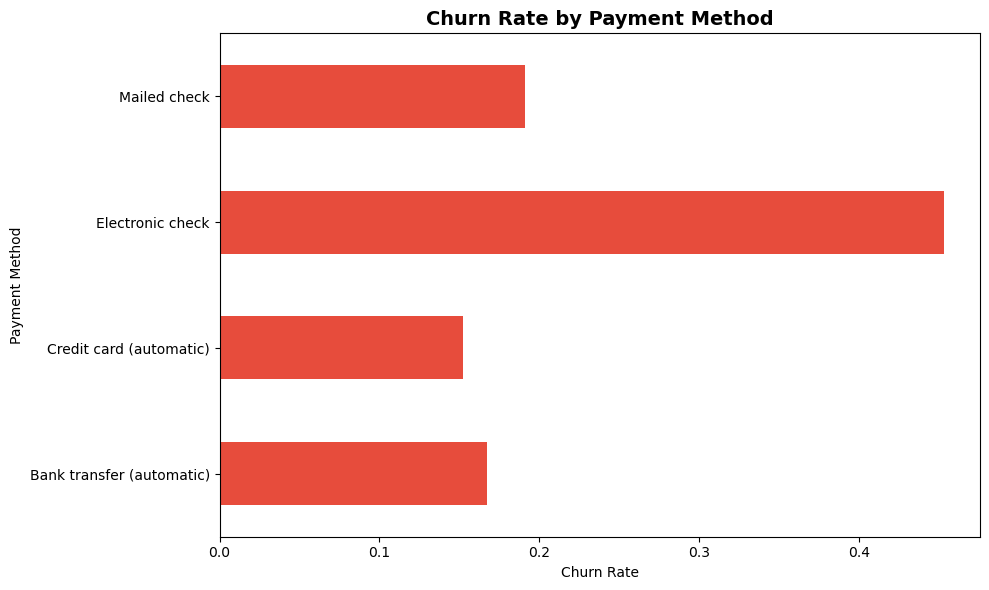

In [22]:
payment_churn = df.groupby('Payment Method')['Churn'].value_counts(normalize=True).unstack()
payment_churn['Yes'].plot(kind='barh', color='#e74c3c', figsize=(10,6))
plt.title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Churn Rate')
plt.tight_layout()
plt.savefig('payment_churn.png', dpi=150)
plt.show()


Churn                 No       Yes
Senior Citizen                    
No              0.763938  0.236062
Yes             0.583187  0.416813


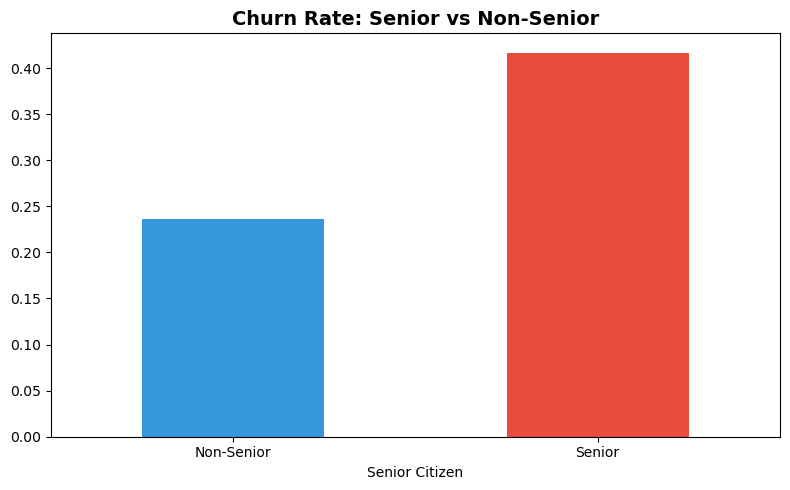

In [23]:
senior_churn = df.groupby('Senior Citizen')['Churn'].value_counts(normalize=True).unstack()
print(senior_churn)

senior_churn['Yes'].plot(kind='bar', color=['#3498db','#e74c3c'], figsize=(8,5))
plt.title('Churn Rate: Senior vs Non-Senior', fontsize=14, fontweight='bold')
plt.xticks([0,1], ['Non-Senior','Senior'], rotation=0)
plt.tight_layout()
plt.savefig('senior_churn.png', dpi=150)
plt.show()


In [25]:
churn_rate = round((df['Churn'].value_counts()['Yes'] / len(df)) * 100, 2)

high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['Tenure'] < 12) &
    (df['Monthly Charges'] > df['Monthly Charges'].median())
]

print('='*50)
print('CUSTOMER CHURN ANALYSIS — KEY FINDINGS')
print('='*50)
print(f'Total Customers: {len(df)}')
print(f'Churned: {df["Churn"].value_counts()["Yes"]} ({churn_rate}%)')
print(f'High Risk Segment: {len(high_risk)} customers')
print()
print('TOP CHURN DRIVERS:')
print('1. Month-to-month contract: 43% churn')
print('2. Fiber Optic internet: 41% churn')
print('3. Electronic check payment: 45% churn')
print('4. Tenure < 12 months: 47% churn')
print('5. Senior citizens: 41% churn')

CUSTOMER CHURN ANALYSIS — KEY FINDINGS
Total Customers: 7043
Churned: 1869 (26.54%)
High Risk Segment: 770 customers

TOP CHURN DRIVERS:
1. Month-to-month contract: 43% churn
2. Fiber Optic internet: 41% churn
3. Electronic check payment: 45% churn
4. Tenure < 12 months: 47% churn
5. Senior citizens: 41% churn


In [26]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('telecom', conn, index=False, if_exists='replace')
print('Data loaded into SQL successfully!')



Data loaded into SQL successfully!


In [27]:
query1 = '''
SELECT
    COUNT(*) as total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned,
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM telecom
'''
print(pd.read_sql_query(query1, conn))


   total_customers  churned  churn_rate_pct
0             7043     1869           26.54


In [28]:
query3 = '''
SELECT
    CASE
        WHEN Tenure <= 12 THEN '0-12 months'
        WHEN Tenure <= 24 THEN '13-24 months'
        WHEN Tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END as tenure_group,
    COUNT(*) as total,
    ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as churn_pct
FROM telecom
GROUP BY tenure_group
ORDER BY churn_pct DESC
'''
print(pd.read_sql_query(query3, conn))


   tenure_group  total  churn_pct
0   0-12 months   2186      47.44
1  13-24 months   1024      28.71
2  25-48 months   1594      20.39
3    49+ months   2239       9.51


In [29]:
query4 = '''
SELECT
    Churn,
    ROUND(AVG("Monthly Charges"),2) as avg_monthly_charge,
    ROUND(AVG("Total Charges"),2) as avg_total_charge,
    ROUND(AVG(Tenure),2) as avg_tenure
FROM telecom
GROUP BY Churn
'''
print(pd.read_sql_query(query4, conn))


  Churn  avg_monthly_charge  avg_total_charge  avg_tenure
0    No               61.27           2549.91       37.57
1   Yes               74.44           1531.80       17.98


In [30]:
query5 = '''
SELECT
    "Internet Service",
    COUNT(*) as total,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) as churned,
    ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as churn_pct
FROM telecom
GROUP BY "Internet Service"
ORDER BY churn_pct DESC
'''
print(pd.read_sql_query(query5, conn))


  Internet Service  total  churned  churn_pct
0      Fiber optic   3096     1297      41.89
1              DSL   2421      459      18.96
2               No   1526      113       7.40


In [31]:
query6 = '''
SELECT
    COUNT(*) as high_risk_customers,
    ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as churn_pct
FROM telecom
WHERE Contract = 'Month-to-month'
    AND Tenure <= 12
    AND "Monthly Charges" > 65
'''
print(pd.read_sql_query(query6, conn))


   high_risk_customers  churn_pct
0                  975      67.69


In [35]:
query7='''
SELECT 
    "Payment Method",
     COUNT(*) as total,
     ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as churn_pct
FROM telecom
GROUP BY "Payment Method"
ORDER BY churn_pct DESC
'''
print(pd.read_sql_query(query7,conn))

              Payment Method  total  churn_pct
0           Electronic check   2365      45.29
1               Mailed check   1612      19.11
2  Bank transfer (automatic)   1544      16.71
3    Credit card (automatic)   1522      15.24


In [36]:
query8 = '''
SELECT
    Contract,
    "Internet Service",
    ROUND(AVG("Monthly Charges"),2) as avg_charges,
    ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as churn_pct,
    RANK() OVER (ORDER BY SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*) DESC) as risk_rank
FROM telecom
GROUP BY Contract, "Internet Service"
ORDER BY risk_rank
LIMIT 5
'''
print(pd.read_sql_query(query8, conn))


         Contract Internet Service  avg_charges  churn_pct  risk_rank
0  Month-to-month      Fiber optic        87.02      54.61          1
1  Month-to-month              DSL        50.22      32.22          2
2        One year      Fiber optic        98.78      19.29          3
3  Month-to-month               No        20.41      18.89          4
4        One year              DSL        61.40       9.30          5


In [37]:
query9 = '''
SELECT
    CASE WHEN "Senior Citizen" = 1 THEN 'Senior' ELSE 'Non-Senior' END as customer_type,
    COUNT(*) as total,
    ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as churn_pct,
    ROUND(AVG("Monthly Charges"),2) as avg_monthly_charge
FROM telecom
GROUP BY "Senior Citizen"
'''
print(pd.read_sql_query(query9, conn))


  customer_type  total  churn_pct  avg_monthly_charge
0    Non-Senior   5901      23.61               61.85
1    Non-Senior   1142      41.68               79.82


In [38]:
query10 = '''
WITH churn_segments AS (
    SELECT
        Contract,
        "Internet Service",
        Churn,
        "Monthly Charges",
        Tenure
    FROM telecom
),
segment_stats AS (
    SELECT
        Contract,
        "Internet Service",
        COUNT(*) as total,
        ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as churn_pct,
        ROUND(AVG("Monthly Charges"),2) as avg_charge
    FROM churn_segments
    GROUP BY Contract, "Internet Service"
)
SELECT * FROM segment_stats
WHERE churn_pct > 30
ORDER BY churn_pct DESC
'''
print(pd.read_sql_query(query10, conn))


         Contract Internet Service  total  churn_pct  avg_charge
0  Month-to-month      Fiber optic   2128      54.61       87.02
1  Month-to-month              DSL   1223      32.22       50.22
